In [1]:
import numpy as np
import ultraplot as uplt
import xarray as xr
import cartopy.crs as ccrs
import pandas as pd
import geopandas as gpd
from shapely.geometry import shape
from rasterio.features import shapes
from affine import Affine
from rasterio.features import rasterize
import xarray as xr
import cartopy.feature as cfeature
from numpy import ma 
from scipy.interpolate import interp1d
from matplotlib.colors import Normalize
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.legend_handler import HandlerLine2D

import rioxarray


uplt.rc.style='seaborn-v0_8-paper'
uplt.rc.update({'tick.len': 2.0, 'tick.dir': 'in', 'font.largesize': 12, 'font.smallsize': 10})

In [2]:
lonlim = (-82, -32)
latlim = (-60, 15)

In [3]:
# Load R² data for 1D CNN model from CSV file
c1d = pd.read_csv('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/567_568_569/c1d_r2.csv')# local-only model

# Load R² data for 3D CNN model from CSV file
c3d = pd.read_csv('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/567_568_569/c3d_r2.csv')# spatial-context model

# Load R² data for kernel-based 3D CNN model from CSV file
kc3d = pd.read_csv('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/567_568_569/c3d-gam_r2.csv')# transport-informed model

In [4]:
# Create pivot table from c1d DataFrame: convert from long to wide format with lat/lon as coordinates
df_pivot_c1d = c1d.pivot_table(index='lat', columns='lon', values='r2')
# Convert pivot table to xarray DataArray with proper dimensions and coordinate labels
da_c1d = xr.DataArray(df_pivot_c1d, dims=('lat', 'lon'), 
                     coords={'lat': df_pivot_c1d.index, 'lon': df_pivot_c1d.columns})

# Create pivot table from c3d DataFrame: convert from long to wide format with lat/lon as coordinates
df_pivot_c3d = c3d.pivot_table(index='lat', columns='lon', values='r2')
# Convert pivot table to xarray DataArray with proper dimensions and coordinate labels
da_c3d = xr.DataArray(df_pivot_c3d, dims=('lat', 'lon'), 
                     coords={'lat': df_pivot_c3d.index, 'lon': df_pivot_c3d.columns})

# Create pivot table from kc3d DataFrame: convert from long to wide format with lat/lon as coordinates
df_pivot_kc3d = kc3d.pivot_table(index='lat', columns='lon', values='r2')
# Convert pivot table to xarray DataArray with proper dimensions and coordinate labels
da_kc3d = xr.DataArray(df_pivot_kc3d, dims=('lat', 'lon'), 
                      coords={'lat': df_pivot_kc3d.index, 'lon': df_pivot_kc3d.columns})

In [5]:
# Calculate difference between kernel-based 3D CNN and 1D CNN R² values
kc3d_c1d = da_kc3d - da_c1d

# Calculate difference between 3D CNN and 1D CNN R² values
c3d_c1d = da_c3d - da_c1d

In [6]:
# Load latitude and longitude coordinate arrays from numpy files
lats = np.load("/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/inv-5/lats_737.npy")
lons = np.load("/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/inv-5/lons_737.npy")

# Load percentage SOM (Soil Organic Matter) data from numpy file
perc_somo = np.load('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/567_568_569/perc_somo.npy')

# Create DataFrame with SOM percentage values and corresponding coordinates, then pivot to 2D grid format
df_pivot_perc_somo = pd.DataFrame({'perc_somo': perc_somo, 'lat': lats, 'lon': lons}).pivot_table(
    index='lat', columns='lon', values='perc_somo')

# Convert pivoted DataFrame to xarray DataArray with proper dimensions and coordinate labels
da_perc_somo = xr.DataArray(df_pivot_perc_somo, dims=('lat', 'lon'), 
                           coords={'lat': df_pivot_perc_somo.index, 'lon': df_pivot_perc_somo.columns})

In [7]:
# Define labels for different environmental variables
labels = ['LAI', 'SST', 'TA', 'SSRD', 'BDOD', 'SAND', 'SILT', 'CLAY']

# Load percentage feature importance (SHAP values) for SOM from numpy file
perc_fv_somo = np.load('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/567_568_569/perc_fv_somo.npy')

In [8]:
# Load Amazon shapefile and read into GeoDataFrame
amazon_shapefile = "/Net/Groups/BGI/work_3/ML4HES/sjiang/plot_exercise/downwind/amazonia_polygons.shp"
amazon_vector = gpd.read_file(amazon_shapefile)

# Dissolve all polygons into a single multi-polygon feature
# (Alternative commented line shows filtering for specific region before dissolving)
amazon_vector = amazon_vector.dissolve()
# amazon_vector = amazon_vector[amazon_vector['name'] == 'Amazonia - sensu stricto'].dissolve()

# Select the first (and only) feature from the dissolved GeoDataFrame
amazon_border = amazon_vector.loc[[0]]

In [9]:
# Load global geography regions shapefile for additional geographic context
geography_shapefile = "/Net/Groups/BGI/work_3/ML4HES/sjiang/plot_exercise/downwind/ne_10m_geography_regions_polys.shp"
geography_vector = gpd.read_file(geography_shapefile)

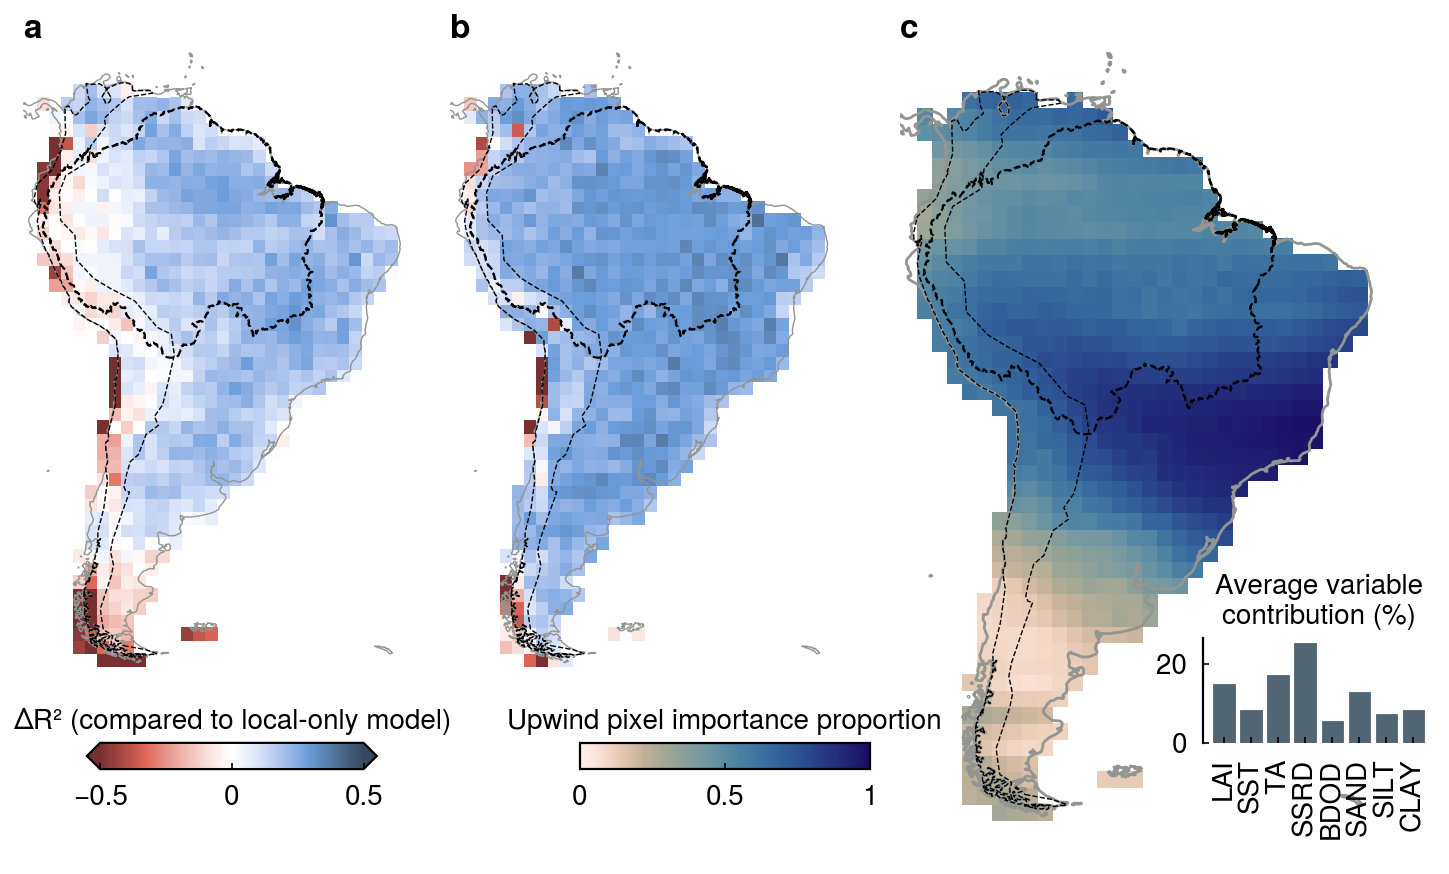

In [10]:
# Define map projection (PlateCarree commented alternative shows AlbersEqualArea option)
# proj = ccrs.AlbersEqualArea(central_longitude=-60, central_latitude=-20, standard_parallels=(-10, -40))
proj = ccrs.PlateCarree()

# Define subplot arrangement (2x3 grid with specific layout)
arrray = [  # the "picture" (0 == nothing, 1 == subplot A, 2 == subplot B, etc.)
    [1, 2, 3],
    [0, 0, 3]
]

# Create figure with specified parameters
fig = uplt.figure(refwidth=2, share=False, span=False, tight=True)
# Create subplots with specified projection and layout parameters
axs = fig.subplots(arrray, projection=proj, abc=True, width_ratios=[1, 1, 1.5], height_ratios=[4, 1])
# Format axes with longitude and latitude limits
axs.format(lonlim=lonlim, latlim=latlim, linewidth=0)

# First subplot: 3D CNN vs 1D CNN R² difference
ax = axs[0]
# Plot R² difference as colormesh
im = ax.pcolormesh(
    c3d_c1d.lon,
    c3d_c1d.lat,
    c3d_c1d.values,
    cmap='negpos_r',
    discrete=False,
    transform=ccrs.PlateCarree(),
    vmin=-0.5, vmax=0.5,
)

# Add geographic features
amazon_border.plot(ax=ax, linewidth=0.8, color='none', linestyle='--', zorder=50)
geography_vector[geography_vector['NAME'] == 'ANDES'].plot(ax=ax, linewidth=0.5, color='none', linestyle='--', zorder=50, ec='k')
ax.add_feature(cfeature.COASTLINE, edgecolor='grey', linewidth=0.5)

################################################
# Second subplot: Kernel-based 3D CNN vs 1D CNN R² difference
ax = axs[1]
# Plot R² difference as colormesh
im = ax.pcolormesh(
    kc3d_c1d.lon,
    kc3d_c1d.lat,
    kc3d_c1d.values,
    cmap='negpos_r',
    discrete=False,
    transform=ccrs.PlateCarree(),
    vmin=-0.5, vmax=0.5,
)

# Add geographic features
amazon_border.plot(ax=ax, linewidth=0.8, color='none', linestyle='--', zorder=50)
geography_vector[geography_vector['NAME'] == 'ANDES'].plot(ax=ax, linewidth=0.5, color='none', linestyle='--', zorder=50, ec='k')

# Create colorbar for R² difference
cax = fig.add_axes([0.06, 0.12, 0.2, 0.03], title='ΔR² (compared to local-only model)', titlesize=10)
fig.colorbar(
    im,
    cax=cax,
    orientation='horizontal',
    extend='both',
    ticks=[-0.5, 0, 0.5],
)
ax.add_feature(cfeature.COASTLINE, edgecolor='grey', linewidth=0.5)

################################################
# Third subplot: Upwind pixel importance proportion
ax = axs[2]
# Plot SOM importance proportion as colormesh
im = ax.pcolormesh(
    da_perc_somo.lon,
    da_perc_somo.lat,
    da_perc_somo.values,
    cmap='lapaz_r',
    discrete=False,
    transform=ccrs.PlateCarree(),
    vmin=0, vmax=1,
)

# Add geographic features
amazon_border.plot(ax=ax, linewidth=0.8, color='none', linestyle='--', zorder=50)
geography_vector[geography_vector['NAME'] == 'ANDES'].plot(ax=ax, linewidth=0.5, color='none', linestyle='--', zorder=50, ec='k')
ax.add_feature(cfeature.COASTLINE, edgecolor='grey', linewidth=1)

# Create inset axes for variable contribution bar chart
ax_inset = fig.add_axes([0.83, 0.15, 0.16, 0.12], title='Average variable\ncontribution (%)', titlesize=10)
# Plot stacked bar chart of feature importance percentages
ax_inset.bar(perc_fv_somo, stack=True, c='slate')
# Format inset axes
ax_inset.format(xticks=[0, 1, 2, 3, 4, 5, 6, 7], 
                yticks=[0, 0.2],
                yticklabels=['0', '20'],
                xticklabels=labels, xspineloc='none', xtickloc='bottom', yspineloc='left', xrotation=90)

# Create colorbar for upwind pixel importance
cax = fig.add_axes([0.40, 0.12, 0.2, 0.03], title='Upwind pixel importance proportion', titlesize=10)
fig.colorbar(
    im,
    cax=cax,
    orientation='horizontal',
    extend='neither',
    ticks=[0, 0.5, 1],
)

In [1]:
# Import numpy library
import numpy as np

# Assume kc3d_c1d.values is an array with shape (45, 30)
data = kc3d_c1d.values  # Get NumPy array

# 1. Remove NaN values and flatten to 1D array (for easier calculation)
valid_data = data[~np.isnan(data)]  # All non-NaN data

# 2. Count number of data points greater than 0
positive_count = np.sum(valid_data > 0)

# 3. Calculate percentage
percentage = (positive_count / len(valid_data)) * 100

# Print the result
print(f"Percentage of non-NaN data greater than 0: {percentage:.2f}%")

In [3]:
94.27

94.27